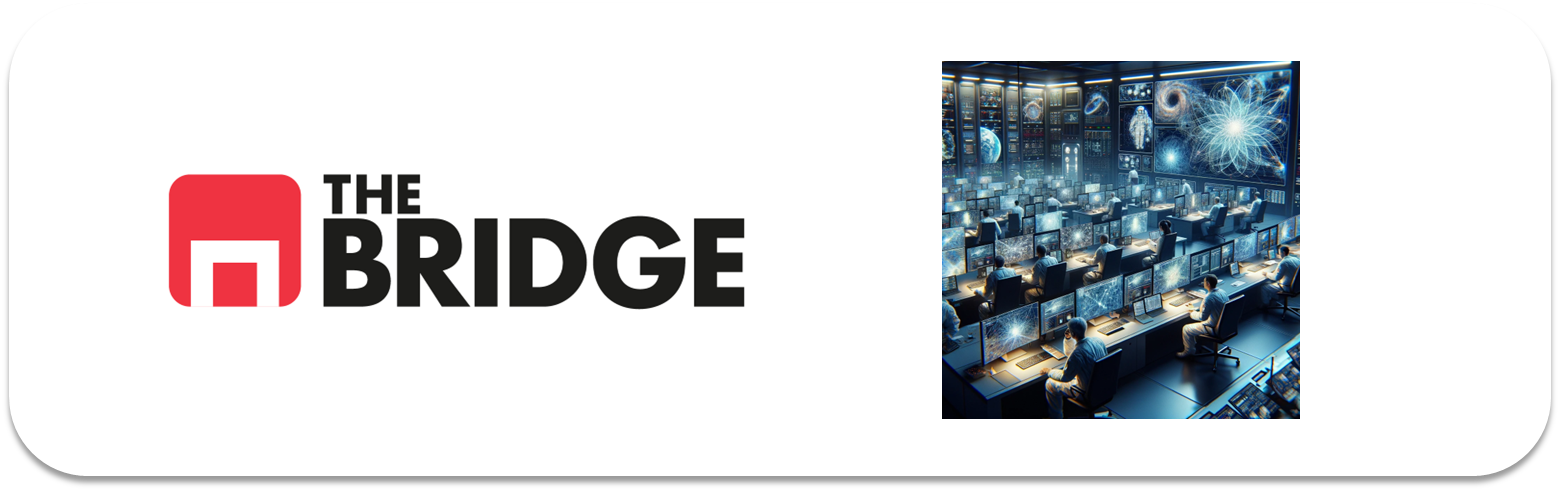

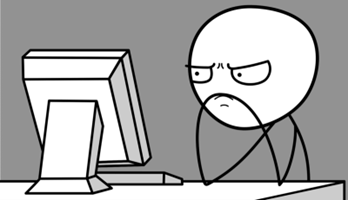

Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone
from threadpoolctl import threadpool_limits
threadpool_limits(2)
SEED=42
np.random.seed(SEED)
ROOT=next(p for p in Path.cwd().parents if (p/'05_Deep_Learning').exists() and (p/'.git').exists())
CACHE=ROOT/'.cache'/'unidades_siguientes'
CACHE.mkdir(parents=True,exist_ok=True)
os.environ['KERAS_HOME']=str(CACHE/'keras')
os.environ['KAGGLEHUB_CACHE']=str(CACHE/'kaggle')
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
tf.keras.utils.set_random_seed(SEED)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)
print('TensorFlow:',tf.__version__,'GPUs:',len(tf.config.list_physical_devices('GPU')))
from PIL import Image
import json
def read_images(folder,size=(32,32),labels_from_filename=False):
 folder=Path(folder);files=sorted(p for p in folder.rglob('*') if p.suffix.lower() in ['.jpg','.jpeg','.png'])
 if not files:raise FileNotFoundError(f'Sin imágenes: {folder}')
 images=[];labels=[]
 for p in files:
  with Image.open(p) as img:images.append(np.asarray(img.convert('RGB').resize(size)))
  labels.append(p.name.split('.')[0] if labels_from_filename else p.parent.name)
 return np.asarray(images,dtype=np.uint8),np.asarray(labels),files
def show_images(images,titles=None,indices=None):
 ids=np.arange(min(10,len(images))) if indices is None else np.asarray(indices)[:10]
 if len(ids)==0:print('Sin imágenes que cumplan el criterio.');return
 fig,axes=plt.subplots((len(ids)+4)//5,5,figsize=(15,3*((len(ids)+4)//5)),squeeze=False)
 for ax in axes.flat:ax.axis('off')
 for ax,i in zip(axes.flat,ids):
  ax.imshow(images[i]);ax.set_title(str(titles[i]) if titles is not None else str(i),fontsize=8)
 plt.tight_layout();plt.show()
def plot_history(history):
 h=pd.DataFrame(history.history)
 fig,axes=plt.subplots(1,2,figsize=(12,4))
 h[['loss','val_loss']].plot(ax=axes[0]);h[['accuracy','val_accuracy']].plot(ax=axes[1]);plt.show()
 print('Mejor época val_loss:',int(h.val_loss.argmin())+1,'de',len(h),'gap accuracy final:',float(h.accuracy.iloc[-1]-h.val_accuracy.iloc[-1]))
def evaluate_model(model,X,y,names):
 probs=model.predict(X,batch_size=128,verbose=0)
 if probs.shape[1]==1:
  probs=np.column_stack([1-probs[:,0],probs[:,0]])
 pred=probs.argmax(axis=1)
 print(classification_report(y,pred,labels=np.arange(len(names)),target_names=names,zero_division=0))
 fig,ax=plt.subplots(figsize=(9,8));ConfusionMatrixDisplay.from_predictions(y,pred,display_labels=names,normalize='true',ax=ax,xticks_rotation=60);plt.show()
 return {'accuracy':accuracy_score(y,pred),'balanced_accuracy':balanced_accuracy_score(y,pred)},probs
def callbacks(patience=4):return [keras.callbacks.EarlyStopping(monitor='val_loss',patience=patience,restore_best_weights=True)]

TensorFlow: 2.21.0 GPUs: 0


## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [2]:
import kagglehub
intel=Path(kagglehub.dataset_download('puneet6060/intel-image-classification',force_download=False))
TRAIN_PATH=intel/'seg_train'/'seg_train';TEST_PATH=intel/'seg_test'/'seg_test'
assert TRAIN_PATH.is_dir() and TEST_PATH.is_dir()

X_train,y_train,files_train=read_images(TRAIN_PATH)
X_test,y_test,files_test=read_images(TEST_PATH)

C:\Users\Usuario\Documents\Codex\2026-09-24\va\work\venv-next\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


Train: (14034, 32, 32, 3) Test: (3000, 32, 32, 3)


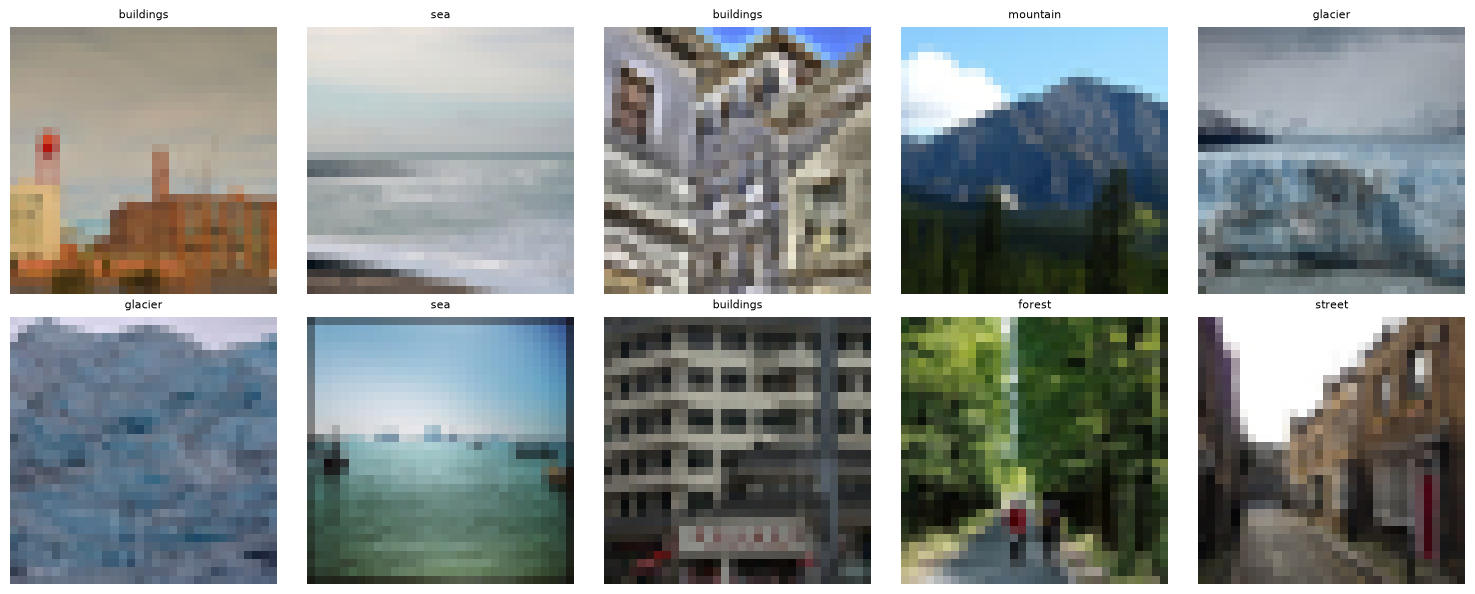

In [3]:
print('Train:',X_train.shape,'Test:',X_test.shape)
show_images(X_train,y_train,np.random.default_rng(SEED).choice(len(X_train),10,replace=False))

### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



In [4]:
display(pd.Series(y_train).value_counts(normalize=True))
print('RGB uint8; el reescalado [0,1] se incluye en el modelo, también para test.')

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64

RGB uint8; el reescalado [0,1] se incluye en el modelo, también para test.


### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [5]:
def build_cnn(size):
 return keras.Sequential([layers.Input((size,size,3)),layers.Rescaling(1/255),
  layers.Conv2D(30,3,padding='same',activation='relu'),layers.MaxPooling2D(),
  layers.Conv2D(15,3,padding='same',activation='relu'),layers.MaxPooling2D(),
  layers.Flatten(),layers.Dense(150,activation='relu'),layers.Dense(100,activation='relu'),layers.Dense(6,activation='softmax')])
model=build_cnn(32)

### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [6]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']);model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 30)     │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 30)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 15)     │         4,065 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 15)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 150)            │       144,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,761 (643.60 KB)

 Trainable params: 164,761 (643.60 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



In [7]:
names=sorted(np.unique(y_train));mapping={name:i for i,name in enumerate(names)}
y_train_num=np.array([mapping[x] for x in y_train]);y_test_num=np.array([mapping[x] for x in y_test])
train_idx,valid_idx=train_test_split(np.arange(len(X_train)),test_size=.2,stratify=y_train_num,random_state=SEED)
history=model.fit(X_train[train_idx],y_train_num[train_idx],validation_data=(X_train[valid_idx],y_train_num[valid_idx]),epochs=25,batch_size=128,callbacks=callbacks(),verbose=2)

Epoch 1/25


88/88 - 3s - 37ms/step - accuracy: 0.5069 - loss: 1.2682 - val_accuracy: 0.5721 - val_loss: 1.0628


Epoch 2/25


88/88 - 2s - 25ms/step - accuracy: 0.6311 - loss: 0.9528 - val_accuracy: 0.6516 - val_loss: 0.9233


Epoch 3/25


...

88/88 - 2s - 25ms/step - accuracy: 0.7871 - loss: 0.5841 - val_accuracy: 0.7221 - val_loss: 0.7544


Epoch 12/25


88/88 - 2s - 25ms/step - accuracy: 0.8000 - loss: 0.5593 - val_accuracy: 0.7403 - val_loss: 0.7138


Epoch 13/25


88/88 - 2s - 25ms/step - accuracy: 0.8121 - loss: 0.5309 - val_accuracy: 0.7399 - val_loss: 0.7254



### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



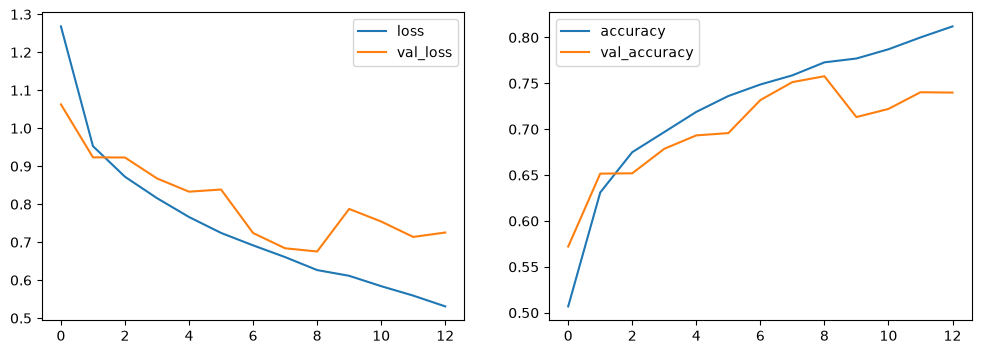

Mejor época val_loss: 9 de 13 gap accuracy final: 0.07212436199188232
El gap y la evolución de val_loss permiten detectar sobreajuste; no se impone una conclusión antes de ejecutar.


In [8]:
plot_history(history)
print('El gap y la evolución de val_loss permiten detectar sobreajuste; no se impone una conclusión antes de ejecutar.')


### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



              precision    recall  f1-score   support

   buildings       0.62      0.77      0.68       437
      forest       0.88      0.92      0.90       474
     glacier       0.77      0.71      0.74       553
    mountain       0.72      0.74      0.73       525
         sea       0.77      0.68      0.72       510
      street       0.82      0.75      0.79       501

    accuracy                           0.76      3000
   macro avg       0.76      0.76      0.76      3000
weighted avg       0.76      0.76      0.76      3000



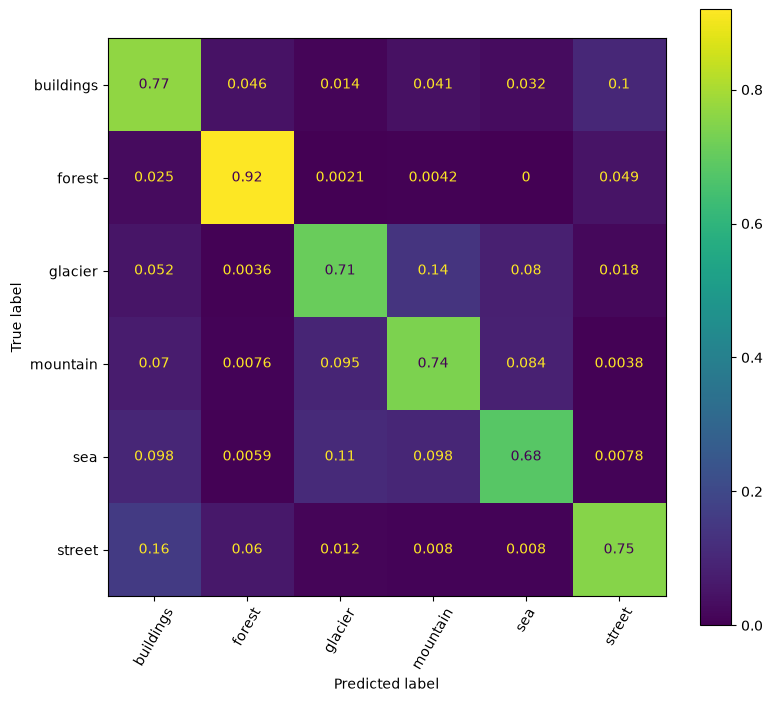

32x32: {'accuracy': 0.759, 'balanced_accuracy': 0.7618623250544238}


In [9]:
score32,probs=evaluate_model(model,X_test,y_test_num,names)
print('32x32:',score32)


### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.





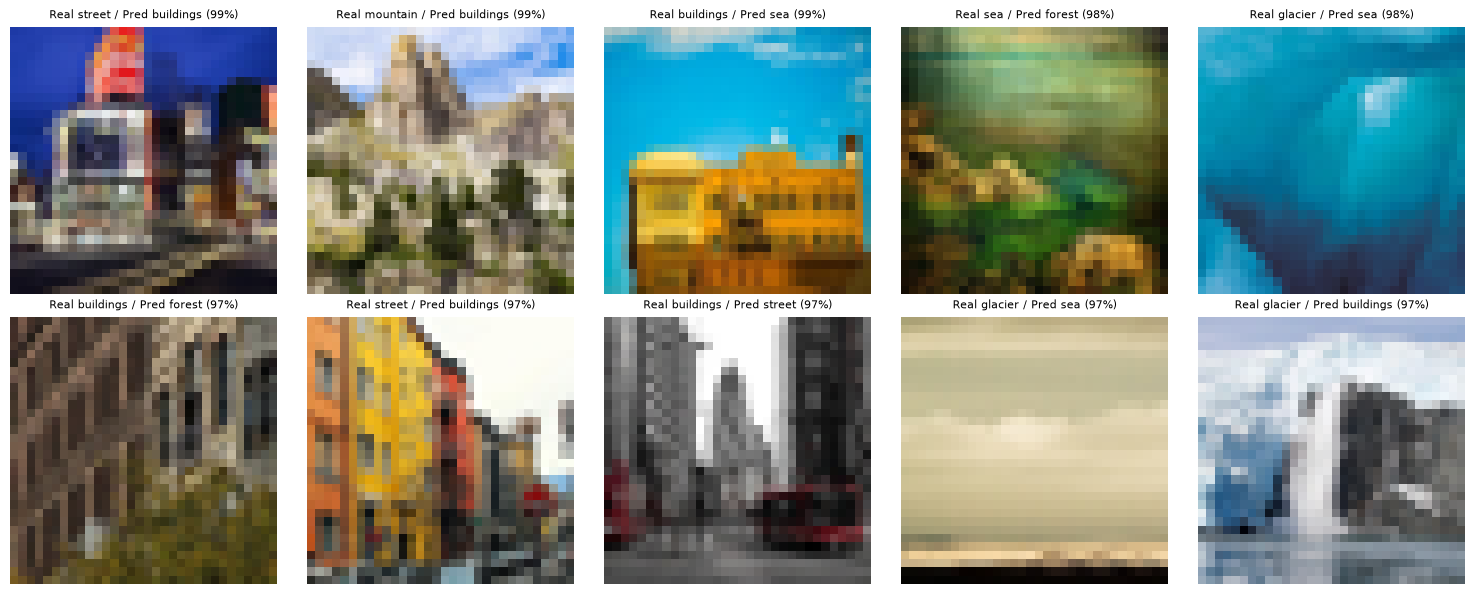

In [10]:
pred=probs.argmax(axis=1);errors=np.flatnonzero(pred!=y_test_num);errors=errors[np.argsort(probs[errors].max(axis=1))[::-1]]
titles=[f'Real {names[a]} / Pred {names[b]} ({c:.0%})' for a,b,c in zip(y_test_num,pred,probs.max(axis=1))]
show_images(X_test,titles,errors)

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

Epoch 1/25


88/88 - 8s - 94ms/step - accuracy: 0.5293 - loss: 1.1987 - val_accuracy: 0.6455 - val_loss: 0.9485


Epoch 2/25


88/88 - 8s - 87ms/step - accuracy: 0.6666 - loss: 0.8930 - val_accuracy: 0.6936 - val_loss: 0.8164


Epoch 3/25


...

88/88 - 7s - 84ms/step - accuracy: 0.8796 - loss: 0.3472 - val_accuracy: 0.7816 - val_loss: 0.6684


Epoch 13/25


88/88 - 7s - 80ms/step - accuracy: 0.8927 - loss: 0.3108 - val_accuracy: 0.7777 - val_loss: 0.7184


Epoch 14/25


88/88 - 7s - 83ms/step - accuracy: 0.8841 - loss: 0.3280 - val_accuracy: 0.7560 - val_loss: 0.7662


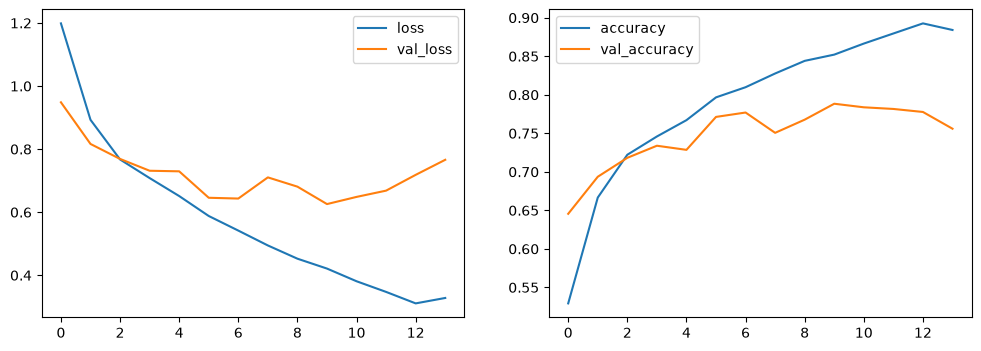

Mejor época val_loss: 10 de 14 gap accuracy final: 0.12815141677856445


In [11]:
keras.backend.clear_session();keras.utils.set_random_seed(SEED)
X_train,y_train,files_train=read_images(TRAIN_PATH,(64,64));X_test,y_test,files_test=read_images(TEST_PATH,(64,64))
model=build_cnn(64) # Misma topología, filtros y neuronas; solo cambia la resolución.
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(X_train[train_idx],y_train_num[train_idx],validation_data=(X_train[valid_idx],y_train_num[valid_idx]),epochs=25,batch_size=128,callbacks=callbacks(),verbose=2)
plot_history(history)

              precision    recall  f1-score   support

   buildings       0.69      0.79      0.73       437
      forest       0.90      0.96      0.93       474
     glacier       0.80      0.67      0.73       553
    mountain       0.69      0.79      0.74       525
         sea       0.78      0.73      0.76       510
      street       0.85      0.77      0.81       501

    accuracy                           0.78      3000
   macro avg       0.79      0.79      0.78      3000
weighted avg       0.79      0.78      0.78      3000



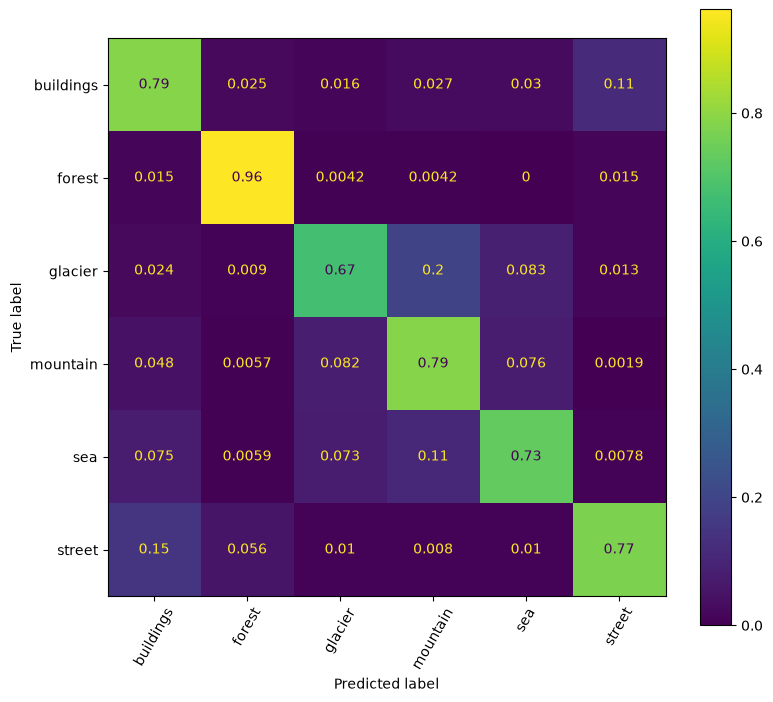

,resolucion,accuracy,balanced_accuracy
0,32,0.759000,0.761862
1,64,0.781667,0.785369


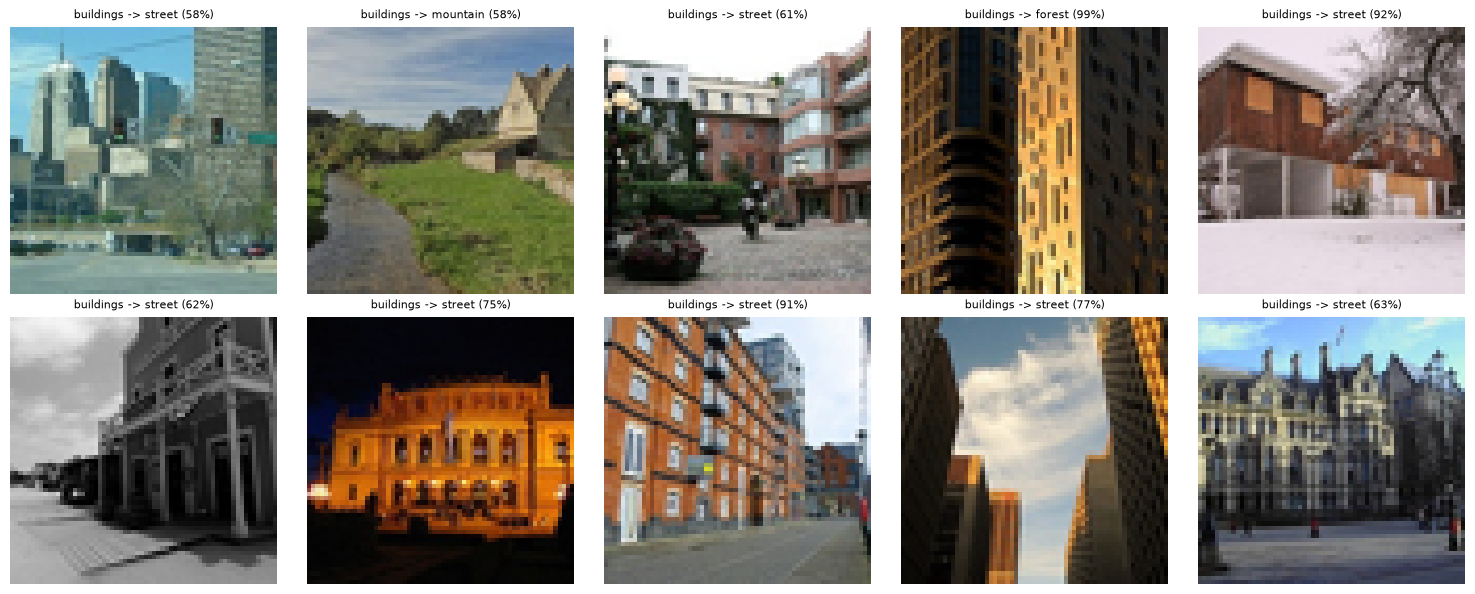

La comparación conserva imágenes, partición y arquitectura; resolución superior no garantiza mejor generalización.


In [12]:
score64,probs=evaluate_model(model,X_test,y_test_num,names)
display(pd.DataFrame([dict(resolucion=32,**score32),dict(resolucion=64,**score64)]))
pred=probs.argmax(axis=1);errors=np.flatnonzero(pred!=y_test_num)
show_images(X_test,[f'{names[a]} -> {names[b]} ({c:.0%})' for a,b,c in zip(y_test_num,pred,probs.max(axis=1))],errors)
(CACHE/'intel_cnn_resultados.json').write_text(json.dumps({'32':score32,'64':score64,'seed':SEED,'n_train':len(X_train),'n_test':len(X_test)}),encoding='utf-8')
print('La comparación conserva imágenes, partición y arquitectura; resolución superior no garantiza mejor generalización.')